# Домашнє завдання: Візуалізація даних з Pandas

## Опис завдання
У цьому домашньому завданні ви працюватимете з датасетом про оренду велосипедів `yulu_rental.csv`. Датасет містить інформацію про кількість орендованих велосипедів залежно від погодних умов, сезону та інших факторів.
Набір даних взяти з Kaggle. Посилання на оригінальний [опис](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data?select=yulu_bike_sharing_dataset.csv).

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів



---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.


Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

## Підготовка даних


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Завантаження даних
df = pd.read_csv('../data/yulu_rental.csv')

In [3]:
df.head ()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [4]:
# Перетворення datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

In [12]:
df.head ()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4


## Завдання 0: Перегляд даних
**Завдання:**
Перегляньте дані, їх розмір, та напишіть висновок:
- скільки даних в наборі
- який рівень деталізації мають ці дані, тобто за який період міститься дані в одному рядку даних ?

In [13]:
df.info

<bound method DataFrame.info of                      season  holiday  workingday  weather   temp   atemp  \
datetime                                                                   
2011-01-01 00:00:00       1        0           0        1   9.84  14.395   
2011-01-01 01:00:00       1        0           0        1   9.02  13.635   
2011-01-01 02:00:00       1        0           0        1   9.02  13.635   
2011-01-01 03:00:00       1        0           0        1   9.84  14.395   
2011-01-01 04:00:00       1        0           0        1   9.84  14.395   
...                     ...      ...         ...      ...    ...     ...   
2012-12-19 19:00:00       4        0           1        1  15.58  19.695   
2012-12-19 20:00:00       4        0           1        1  14.76  17.425   
2012-12-19 21:00:00       4        0           1        1  13.94  15.910   
2012-12-19 22:00:00       4        0           1        1  13.94  17.425   
2012-12-19 23:00:00       4        0           1        

In [14]:
df.shape

(10886, 19)

In [16]:
df ['year'].unique ()

array([2011, 2012], dtype=int32)

В наборі даних наразі є 19 колонок і 10886 колонок. Рівень деталізації становить 1 годину доби. 

## Завдання 1: Базовий лінійний графік

**Завдання:**
1. Згрупуйте дані про кількість орендованих велосипедів (`count`) поденно.
2. Побудуйте з методом `DataFrame.plot()` лінійний графік поденної кількості орендованих велосипедів (`count`) за весь період в даних.
3. Налаштуйте розмір графіка (12x6), додайте заголовок "Динаміка оренди велосипедів" та сітку.
4. Дайте відповіді на питання по цьому графіку. Якщо треба - проведіть додаткові програмні операції для відповідей.

**Питання для інтерпретації:**
1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
2. Які загальні тенденції ви бачите на графіку?
3. Чи помітні якісь сезонні коливання?
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?


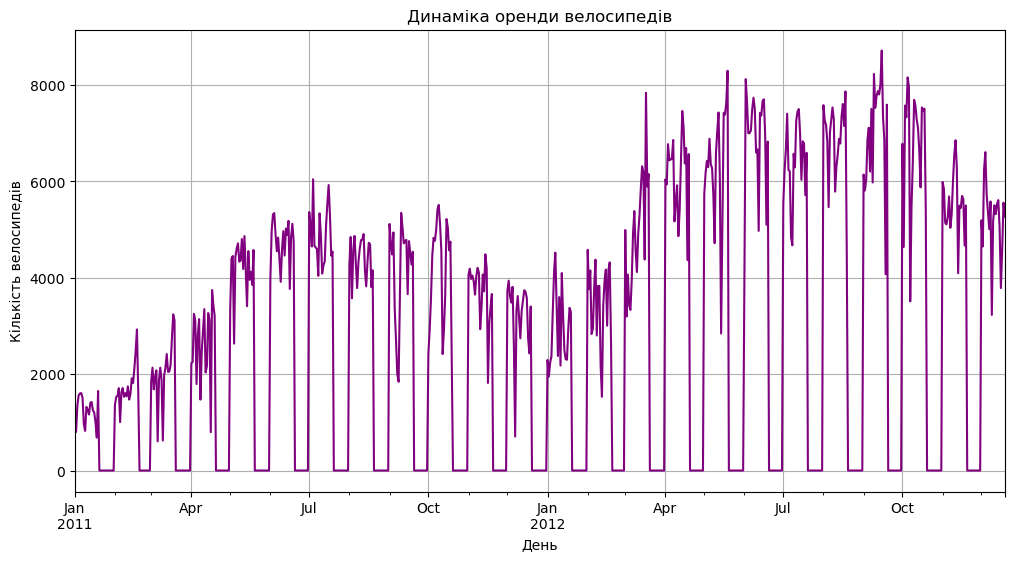

In [51]:
daily_rent = df['count'].resample ('D'). sum ()
daily_rent.plot (
    figsize = (12,6),
    title = 'Динаміка оренди велосипедів',
    xlabel = 'День',
    ylabel = 'Кількість велосипедів',
    color = 'purple',
    grid = True
);

1. Наявність заломів на графіку спричинена щоденними коливаннями попиту, що залежить від погодних умов та типу дня (робочий/вихідний). Позбутися заломів можна наприкладякщо зробити ресемплвнг потижневе або помісячно , але атким чином аналіз не буде таким детальним і важче буде прослідкувати залежність від конкретних погодніх умов в день. 
2, 3. Спостерігається загальна тенденція зростання попиту та виражена сезонність: найвищі значення припадають на період з квітня до жовтня, сезон літній та сезон мусонів. Ця тенденція повторюється і в 2011 і в 2012 рр. Найнижчі показники припадають на зимовий період.
4. Присутні аномальні піки та спади можуть бути пов’язані з погодними умовами або святами.


## Завдання 2: Аналіз сезонності (Bar Plot)

**Завдання:**
Побудуйте вертикальну стовпчасту діаграму середньої кількості орендованих велосипедів за сезонами(кварталами). Додайте підписи осей і заголовок.

Просунуте доповнення:
1. Позначте квартали не числом, а назвою на візуалізації.
2. Додайте підписи над стовпцями зі значеннями в кожному стовпці.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В який квартал найбільша середня кількість оренди велосипедів?
2. Як ви можете пояснити таку сезонну закономірність?
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

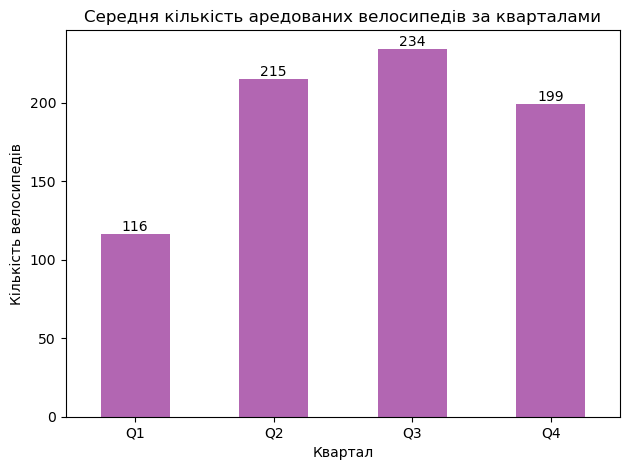

In [45]:
# групуємо дані в колонці count по кварталах
quarterly = df.groupby ('season') ['count']. mean ()

# додаємо підписи стовпчикам
quarterly.index = ['Q1','Q2','Q3','Q4']

ax = quarterly.plot.bar(
    title = 'Середня кількість аредованих велосипедів за кварталами',
    xlabel = 'Квартал',
    ylabel = 'Кількість велосипедів',
    color = 'purple',
    alpha = 0.6
)

# додаємоо піписи до стовпців
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.xticks (rotation = 0)
plt.tight_layout ()

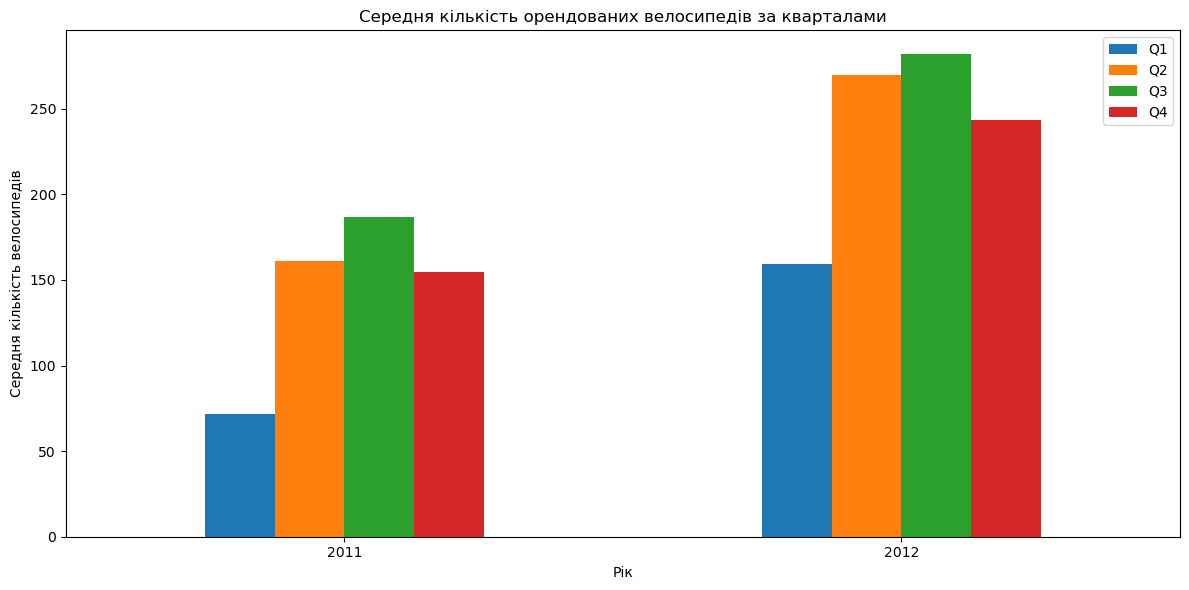

In [43]:
 # інший варіант якщо квартали по роках
quarterly_2 = (
    df.groupby(["year", "season"])["count"]
      .mean()
      .unstack("season")
)

quarterly_2.columns = ["Q1", "Q2", "Q3", "Q4"]

ax = quarterly_2.plot.bar(
    figsize=(12,6), 
    title = 'Середня кількість орендованих велосипедів за кварталами',
    xlabel = 'Рік',
    ylabel = 'Середня кількість велосипедів'
)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()      


 1. Найбільша середня кількість оренди велосипедів в 3 кварталі
2. Така сезонна закономірність впершу чергу може бути повязана з погодними умовами. 3 квартал співпадає з періодом Monsoon/ В цей період через мусон температура стає більш комфортною для їзди ніж в літній період спеки. З іншого боку місони це  часті корокочасні дощі, а в дощі можуть бути перебої з транспортом, затори. Можзиво є якійсь звязок з періодом навчання в навчальних закладах, що може збільшувати кількість поїздок велосипедом.
3. Середня кількість арендованих велосипедів між найпопулярнішим та найменш популярним кварталми відрізняється в 2 рази. Тобто у піковий сезон в 2 рази більшеив середньому арендують велосипеди.

In [47]:
ratio = quarterly.max() / quarterly.min()
ratio

np.float64(2.0148749597441986)

## Завдання 3: Динаміка за місяцями (Line Plot)

**Завдання:**
Створіть лінійний графік середньої кількості оренди велосипедів по місяцях (тобто групування в рамках місяця і беремо середню кількість оренд в цей місяць з кількох років). Використайте маркери-кружечки для точок, додайте сітку та пофарбуйте лінію у червоний колір.

Просунуте доповнення:
- додайте аби по осі ОХ поділки були чітко на кожен окремий місяць по одній. Тобто сумарно 12 поділок.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які місяці спостерігається пік та спад оренди?
2. Чи збігається ця закономірність з результатами з попереднього завдання?
3. Як може вплинути клімат на оренду велосипедів протягом року?


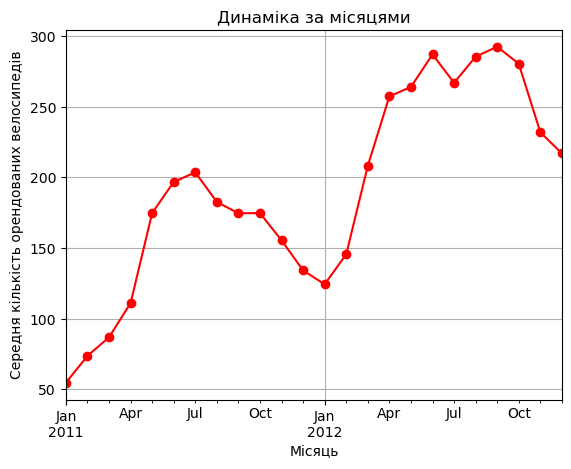

In [56]:
monthly_rent = df ['count'].resample ('ME').mean ()
monthly_rent. plot (
    marker = 'o',
    grid = True,
    color = 'red',
    title = 'Динаміка за місяцями',
    xlabel = 'Місяць',
    ylabel = 'Середня кількість орендованих велосипедів'
);


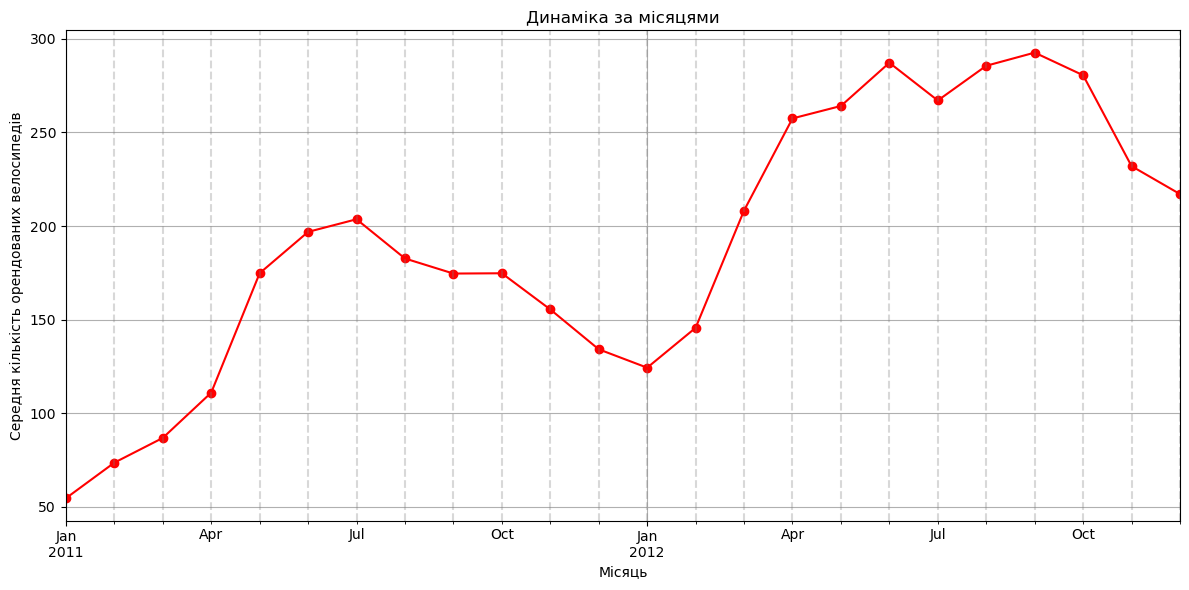

In [57]:
monthly_rent = df ['count'].resample ('ME').mean ()
fig, ax = plt.subplots(figsize=(12,6))
monthly_rent.plot(
    ax=ax,
    marker='o',
    grid=True,
    color='red',
    title='Динаміка за місяцями',
    xlabel='Місяць',
    ylabel='Середня кількість орендованих велосипедів'
)

# Додаємо вертикальні лінії
for date in monthly_rent.index:
    ax.axvline(date, color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

1. Найбільша кількість по місяцях в червні і в вересні. Найменша в січні та лютому
2. Ця закономірність повністю збігається з попередніми результатами і висновками 
3. Клімат дуже впливає на аренду такого виду транспорту як велосипед. В першу чергу в силу особливостей його конструкціїї і т.д. Порівняно з машиною, якою можа пересуватись в будь яку пору року і дня і т.д.

## Завдання 4: Розподіл погодних умов (Pie Chart)

**Завдання:**
1. Побудуйте кругову діаграму з часткою записів за погодними умовами
2. Додайте підписи з відсотками та легенду з описами погоди (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ).
3. Визначте свої відмінні від стандартних кольори для відображення кожної категорії.
4. Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. Яка погода переважає в датасеті?
2. Чи є дні із сильним дощем? Яка їх частка?
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

Очікуваний результат:

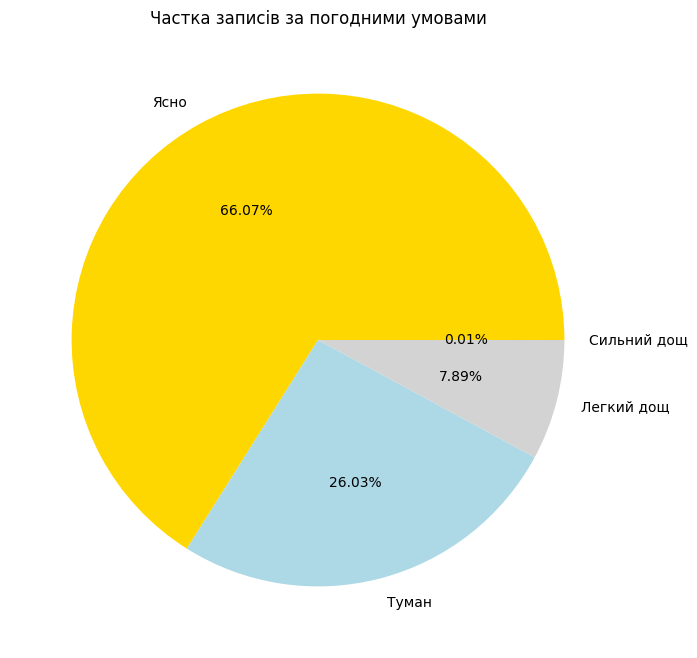

In [58]:
# створюємо колонку з описами погоди
weather_labels = {1: "Ясно", 2: "Туман", 3: "Легкий дощ", 4: "Сильний дощ"}
df["weather_desc"] = df["weather"].map(weather_labels)
df

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour,weather_desc
datetime,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0,Ясно
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1,Ясно
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2,Ясно
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3,Ясно
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4,Ясно
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336,2012-12-19,19,51,2,Wednesday,2012,12,19,Ясно
2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241,2012-12-19,19,51,2,Wednesday,2012,12,20,Ясно
2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168,2012-12-19,19,51,2,Wednesday,2012,12,21,Ясно


In [59]:
# робимо нову колонку категоріальною
order = ["Ясно", "Туман", "Легкий дощ", "Сильний дощ"]
df["weather_desc"] = pd.Categorical(df["weather_desc"], categories=order, ordered=True)
df["weather_desc"].dtype

CategoricalDtype(categories=['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ'], ordered=True, categories_dtype=str)

In [62]:
weather_count = df ['weather_desc'].value_counts().sort_index ()
weather_count

weather_desc
Ясно           7192
Туман          2834
Легкий дощ      859
Сильний дощ       1
Name: count, dtype: int64

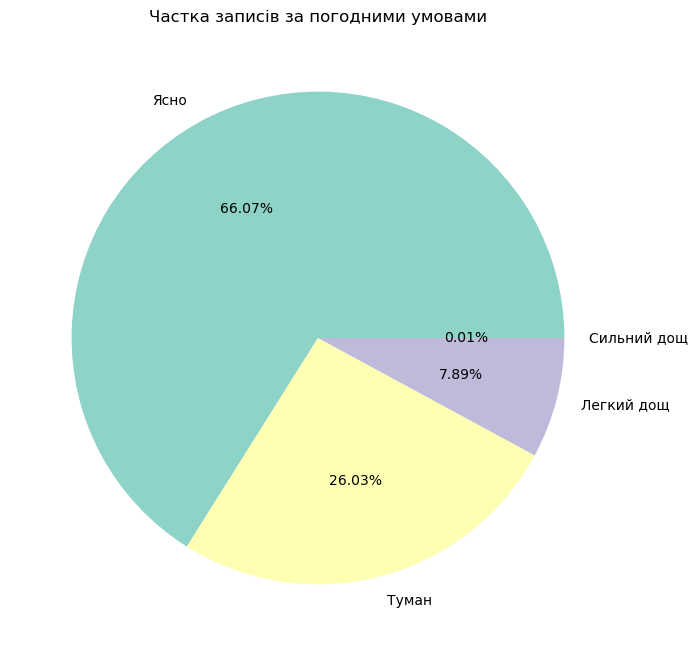

In [68]:
weather_count.plot.pie(
    figsize = (8,8),
    autopct = '%1.2f%%',
    title = 'Частка записів за погодними умовами',
    colors = plt.cm.Set3.colors
);

In [66]:
# інший варіант без окремої колонки
weather_count_1 = df ['weather'].value_counts().sort_index ()
weather_count_1

weather
1    7192
2    2834
3     859
4       1
Name: count, dtype: int64

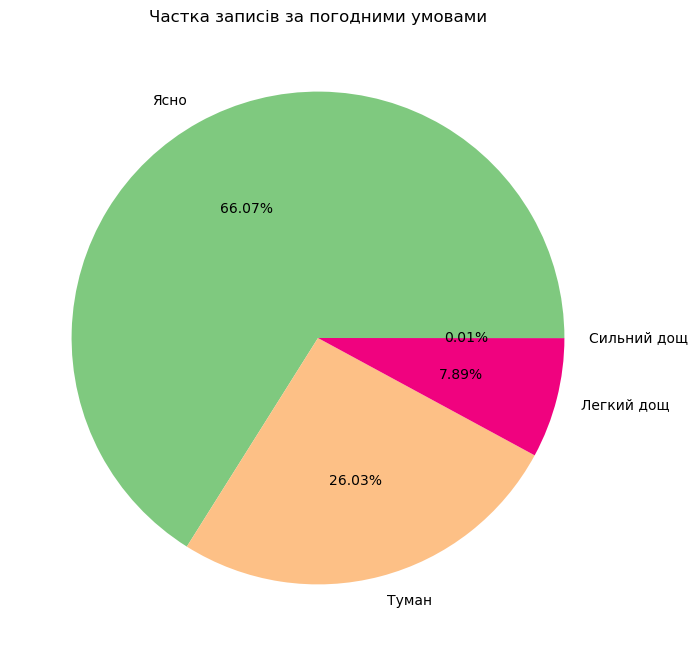

In [107]:
weather_count_1.plot.pie(
    figsize = (8,8),
    autopct = '%1.2f%%',
    title = 'Частка записів за погодними умовами',
    labels = ['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ'],
    colormap = 'Accent'
);

1. Переважає ясна погода в датасеті.
2. Дні з сильним дощем в дуже малій кількості, їхня частка складає 0,01%.
3. Погодні умови мають сильний вплив на попит оренди велосипедів через специфіку цього виду транспорту. Так тепла, ясна погода і без дощу сприяє попиту, адже є комфортними умовами для перебування на вулиці і їзди на велосипеді. Інакше холод, дощ можу сприяти зменшенню попиту. Хоча, як зазначалось у відповіді на одне з попередніх завдань, дощ може мати і інший вплив. Навпаки уникнення заторів після дощу, або якщо дощ легкий за теплої погоди, може сприяти більшому попиту на оренду.
Тут варто зазначити, що погода є важливим фактором впливу на попит, але не єдиним.

## Завдання 5: Box Plot для аналізу викидів

**Завдання:**
Створіть коробковий графік (box plot) кількості орендованих велосипедів для кожного типу погоди.

Просунуте доповнення:
- Використайте горизонтальну орієнтацію.
- Позначте погодні умови не числом, а назвою на візуалізації.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. При якій погоді найбільший розкид у кількості оренди?
2. Чи є викиди (outliers) в даних? При якій погоді?
3. При якій погоді медіанне значення оренди найвище?

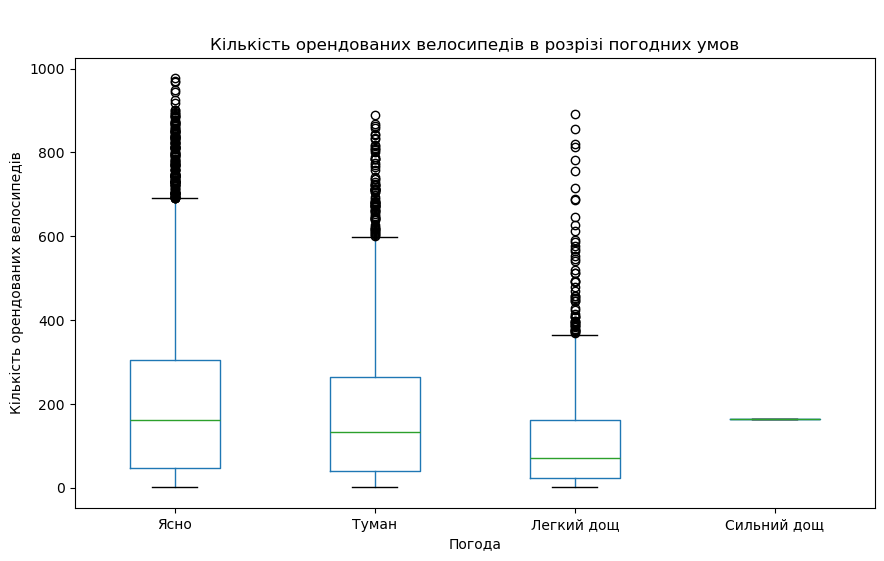

In [77]:
df.boxplot(
    figsize = (10, 6),
        column = 'count',
    by = 'weather_desc',
    grid = False,
    xlabel = 'Погода',
    ylabel = 'Кількість орендованих велосипедів'
)
plt.title ('Кількість орендованих велосипедів в розрізі погодних умов')
plt.suptitle (' ');
    

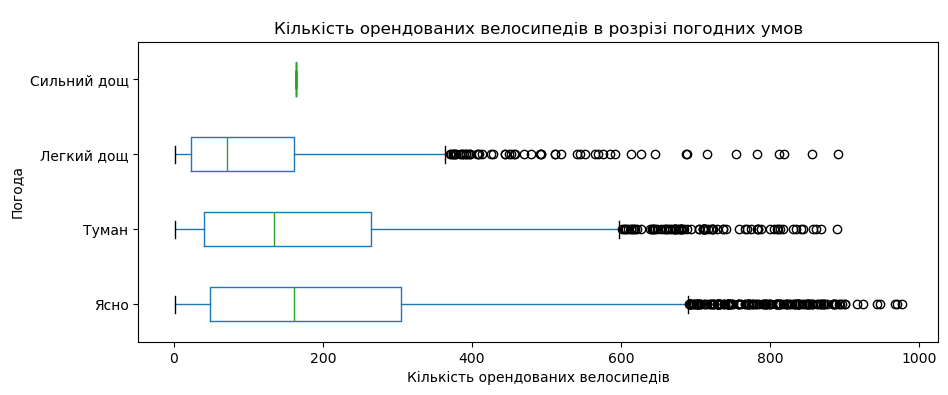

In [82]:
df.boxplot(
    figsize = (10, 4),
    vert= False,
    column = 'count',
    by = 'weather_desc',
    xlabel = 'Кількість орендованих велосипедів',
    ylabel = 'Погода',
    grid = False
)
plt.title ('Кількість орендованих велосипедів в розрізі погодних умов')
plt.suptitle (' ');

1. Найбільший розкид даних за ясної погоди (найдовші вуса і коробка)
2. Викиди мають всі погодні умови крім сильного дощу. За сильного дощу дуже сконцентровані дані
3. За ясної погоди медіанне значення оренди найвище
Отже, найбільше оренд — у ясну погоду. Сильний дощ суттєво знижує попит. У ясну погоду також найбільша варіативність (можливо через вихідні, температуру, сезонність). Викиди — це дні з аномально високим попитом (можливо свята, теплі дні, події).

## Завдання 6: Кореляція температури та оренди (Scatter Plot)

**Завдання:**
Побудуйте діаграму розсіювання залежності між температурою (`temp`) та загальною кількістю оренди (`count`). Розфарбуйте точки за сезонами, додайте напівпрозорість (alpha=0.6).

**Увага!** За замовченням буде колір

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
- Чи є зв'язок між температурою та кількістю оренди? Який?

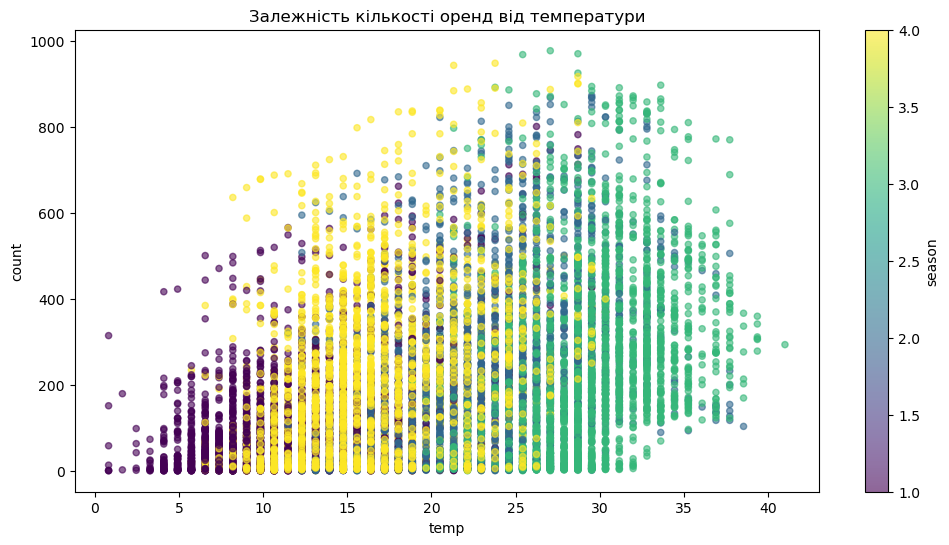

In [99]:
df.plot.scatter(
    figsize = (12, 6),
    x = 'temp',
    y = 'count',
    c = 'season',
    colormap = 'viridis',
    alpha = 0.6,
    title = 'Залежність кількості оренд від температури'
);

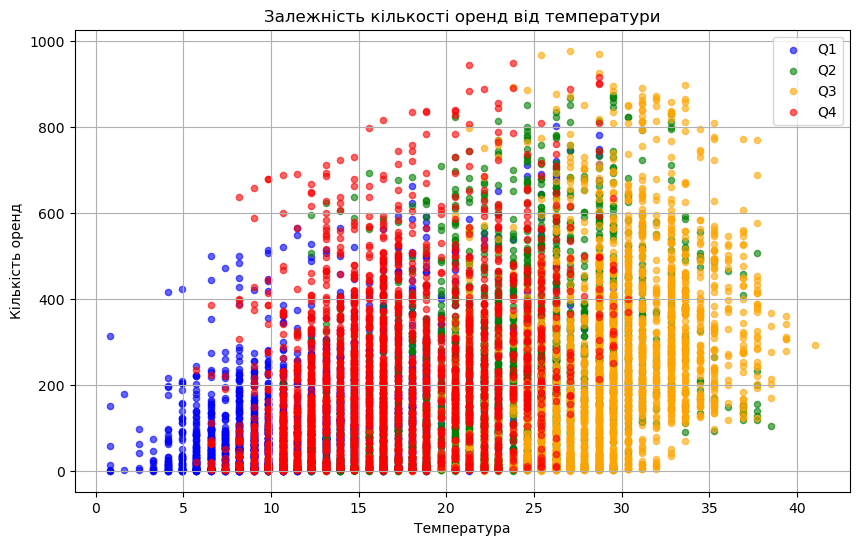

In [100]:
# Створюємо фігуру та осі
fig, ax = plt.subplots(figsize=(10,6))

# Кольори для кожного сезону
colors = {
    1: "blue",
    2: "green",
    3: "orange",
    4: "red"
}

# Проходимо по кожному сезону за допомогою цикла
for season in sorted(df["season"].unique()):
    
    # Вибираємо тільки рядки цього сезону
    subset = df[df["season"] == season]
    
    # Малюємо scatter для цього сезону
    subset.plot.scatter(
        x="temp",
        y="count",
        color=colors[season],
        alpha=0.6,
        ax=ax,               # малюємо на тому ж графіку
        label=f"Q{season}"   # підпис для легенди
    )

# Налаштовуємо графік
ax.set_title("Залежність кількості оренд від температури")
ax.set_xlabel("Температура")
ax.set_ylabel("Кількість оренд")
ax.grid(True)

plt.show()

Згідно з візуалізацією на графіку існує пряма залежність кількості оренд від температури. З підвищенням температури кількість оренд збільшується. Також за дуже низьких або дуже високих температур кількість оренд значно менша ніж за комфортних температур. Так найбільша кількість оренд при темперарурах 20-30 градусів. Прослідковується також різниці між сезонами. В Q1 найменша кількість оренд.

## (Опціонально) Завдання 7: Порівняння користувачів (Stacked Bar Chart)

**Завдання:**
Ми хочемо дізнатись як по дням тижня беруть в середньому в оренду велосипеди випадкові і зареєстровані користувачі.

Створіть стовпчасту діаграму з накопиченням (bar з налаштуванням `stacked=True`), яка показує співвідношення випадкових (`casual`) та зареєстрованих (`registered`) користувачів по днях тижня за кількістю взятих ними велосипедів в оренду в середньому. Використайте різні кольори для типів користувачів.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які дні тижня більше оренд від зареєстрованих користувачів?
2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?

In [102]:
df. head ()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour,weather_desc
datetime,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0,Ясно
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1,Ясно
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2,Ясно
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3,Ясно
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4,Ясно


In [ ]:
# задаємо правильний порядок дням тижня через категорікал
order = ["Monday", "Tuesday", "Wednesday", "Thursday",
         "Friday", "Saturday", "Sunday"]

df["weekday"] = pd.Categorical(df["weekday"], categories=order, ordered=True)

In [103]:
# групуємо і знаходимо середнє
weekday_avg = df.groupby("weekday")[["casual", "registered"]].mean()
weekday_avg

,casual,registered
weekday,,
Friday,31.001962,166.842381
Monday,29.843972,160.546744
Saturday,63.625000,133.040404
Sunday,57.051298,123.788474
Thursday,24.007083,173.289118
Tuesday,22.979207,166.744639
Wednesday,22.521599,165.889749


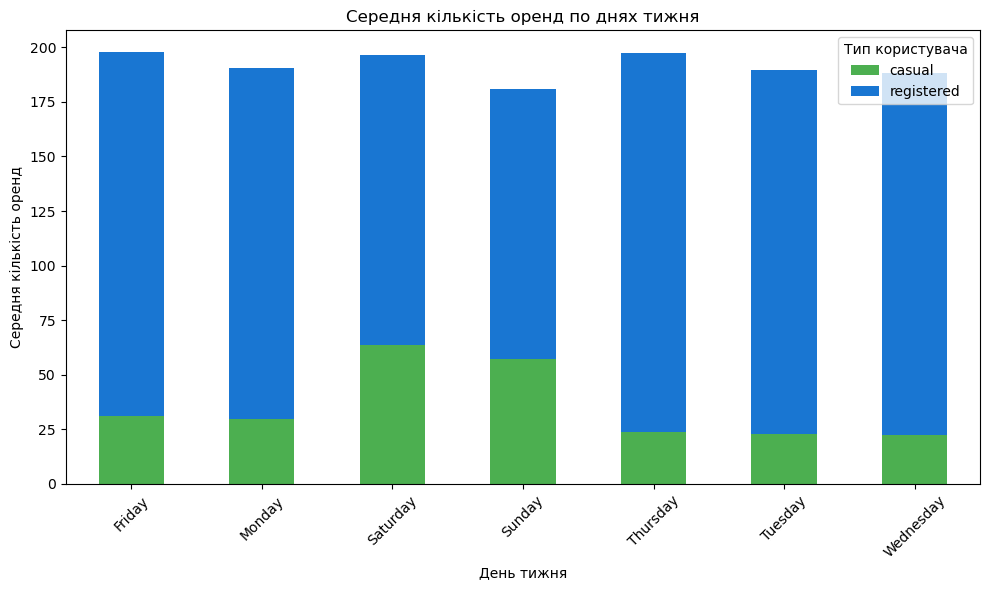

In [105]:
# будуємо графік
weekday_avg.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6),
    color=["#4CAF50", "#1976D2"]  # різні кольори
)
plt.title("Середня кількість оренд по днях тижня")
plt.xlabel("День тижня")
plt.ylabel("Середня кількість оренд")
plt.xticks(rotation=45)
plt.legend(title="Тип користувача")
plt.tight_layout()
plt.show()

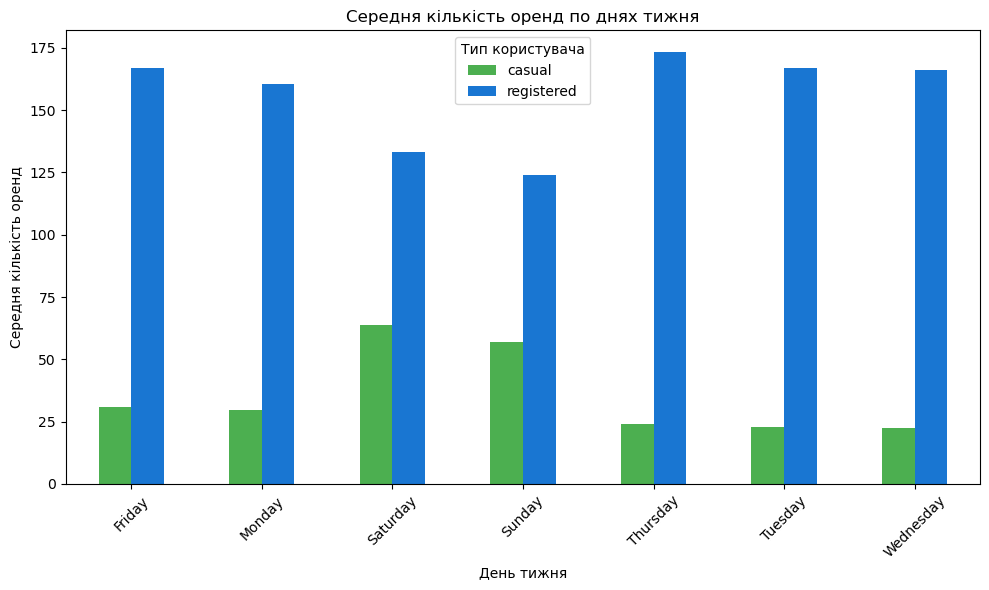

In [106]:
weekday_avg.plot(
    kind="bar",
    figsize=(10,6),
    color=["#4CAF50", "#1976D2"]  # різні кольори
)
plt.title("Середня кількість оренд по днях тижня")
plt.xlabel("День тижня")
plt.ylabel("Середня кількість оренд")
plt.xticks(rotation=45)
plt.legend(title="Тип користувача")
plt.tight_layout()
plt.show()

1. Протягом тижня саме в робочі дні є більше оренд від зареєстрованих користувачів. Ситуація ж з випадковими користувачами протилежна, більше аренд ввд них прослідковується саме у вихідні дні - Субота і неділя. 
2. Чому так відбувається:
    Registered users: Це люди, які користуються велосипедом регулярно, часто — для ком’ютингу. Вони мають підписку. У будні стабільний графік (поїздки вранці та ввечері) і менша залежність від "дозвілля". Тому в понеділок–п’ятницю оренд більше.
    Casual users: Можливо це туристи або дюди, які катаються "для відпочинку". Це разові користувачі. У вихідні Більше вільного часу, прогулянки за гарної погоди, активний відпочинок. Тому  пік у суботу та неділю.
    Отже поведінкова логіка зареєстрованих - практична (транспорт), а випадкових користувачів - рекреаційна (відпочинок).
Тобто бізнесу важливо у будні підтримувати стабільність сервісу для забезпечення його якості для постійних зареєстрованих користувачів. Також можливо пропонувати акції для registered у робочі дні А у вихідні потрібно масштабувати потужності. Перед вихідними можна запускати маркетингові акції спрямовані на casual users.